# Lab1 - Learning with Limited Data

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki

In this scenario, we will investigate the performance of various models when only limited labeled training data is available.

## 1. Import the necessary libraries

In [64]:
import numpy as np


## 2. Load a dataset

In [65]:
from sklearn import datasets
dataset = datasets.fetch_covtype()

### Dataset description

Source: https://archive.ics.uci.edu/ml/datasets/Covertype

Given is the attribute name, attribute type, the measurement unit and a brief description. The forest cover type is the classification problem. The order of this listing corresponds to the order of numerals along the rows of the database.

Name / Data Type / Measurement / Description

- Elevation / quantitative /meters / Elevation in meters
- Aspect / quantitative / azimuth / Aspect in degrees azimuth
- Slope / quantitative / degrees / Slope in degrees
- Horizontal_Distance_To_Hydrology / quantitative / meters / Horz Dist to nearest surface water features
- Vertical_Distance_To_Hydrology / quantitative / meters / Vert Dist to nearest surface water features
- Horizontal_Distance_To_Roadways / quantitative / meters / Horz Dist to nearest roadway
- Hillshade_9am / quantitative / 0 to 255 index / Hillshade index at 9am, summer solstice
- Hillshade_Noon / quantitative / 0 to 255 index / Hillshade index at noon, summer soltice
- Hillshade_3pm / quantitative / 0 to 255 index / Hillshade index at 3pm, summer solstice
- Horizontal_Distance_To_Fire_Points / quantitative / meters / Horz Dist to nearest wildfire ignition points
- Wilderness_Area (4 binary columns) / qualitative / 0 (absence) or 1 (presence) / Wilderness area designation
- Soil_Type (40 binary columns) / qualitative / 0 (absence) or 1 (presence) / Soil Type designation

Target variable:

- Cover_Type (7 types) / integer / 1 to 7 / Forest Cover Type designation

### Basic statistics

In [66]:
X, y = dataset.data, dataset.target
print(f"Descriptive features shape: {X.shape}, target variable shape: {y.shape}")
y_unique, y_counts = np.unique(y, return_counts=True)
print("Unique targets:")
print(y_unique)
#print("Unique targets number:")
#print(y_counts)
print(f"Distribution of targets: {y_counts / y.shape[0]}")

Descriptive features shape: (581012, 54), target variable shape: (581012,)
Unique targets:
[1 2 3 4 5 6 7]
Distribution of targets: [0.36460521 0.48759922 0.06153746 0.00472796 0.01633873 0.02989095
 0.03530048]


## 3. Visualize the data

### UMAP

Project the dataset into 2d space to visualize it and better understand the dataset characteristics.

Use **UMAP** (Uniform Manifold Approximation and Projection for Dimension Reduction) algorithm from **umap-learn** library: https://pypi.org/project/umap-learn.

It learns the low dimensional embedding of the data that locally preserves the distances between the data points.

Read more about the algorithm the following paper of Leland McInnes, John Healy, James Melville: https://arxiv.org/abs/1802.03426

For now it is used as a blackbox for dimensionality reduction method.

58101


C:\Users\elg23\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


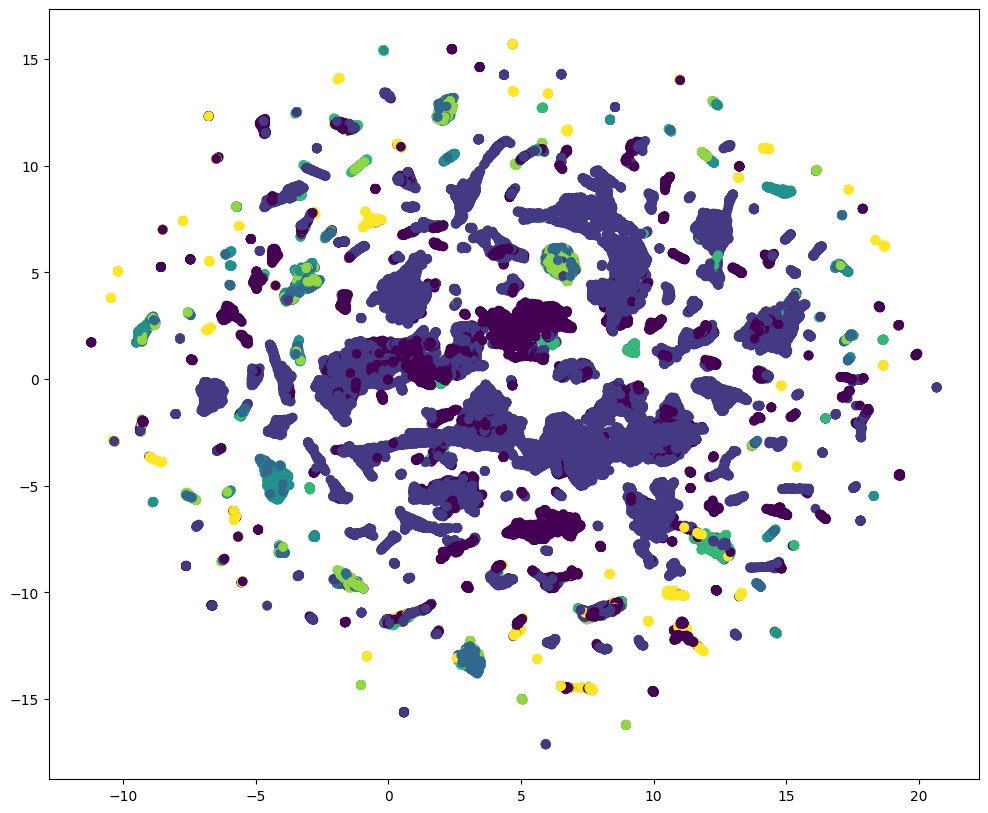

In [67]:
import umap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data_subset = X[:(len(X)//10)]

print((len(X)//10))

plt.figure(figsize=(12, 10))
plot_data = umap.UMAP(n_neighbors=10).fit_transform(StandardScaler().fit_transform(data_subset))
plt.scatter(plot_data[:, 0], plot_data[:, 1], c=y[:(len(X)//10)])
plt.show()


### t-SNE

Use **t-SNE** (t-distributed Stochastic Neighbor Embedding) algorithm from **sklearn.manifold** library to visualize the dataset in 2d space.

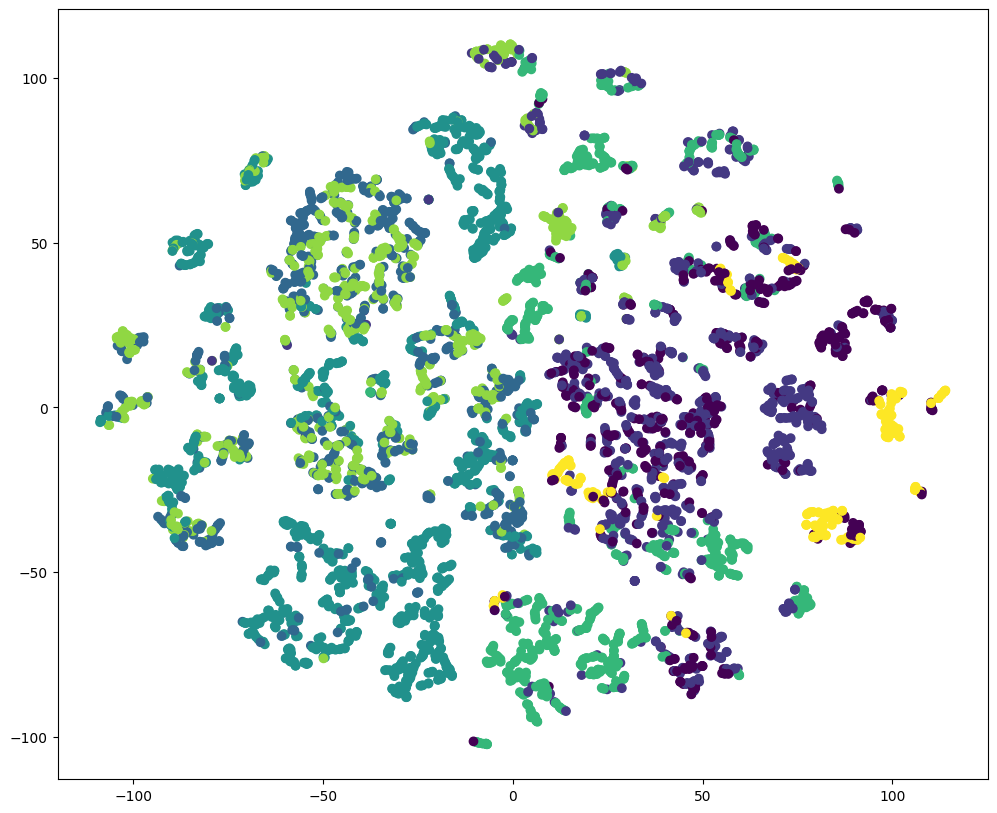

In [68]:
# write your code here
from sklearn.manifold import TSNE

data_subset = X[:(len(X)//100)]

plt.figure(figsize=(12, 10))
plot_data = TSNE(n_components=2, perplexity=10).fit_transform(StandardScaler().fit_transform(data_subset))
plt.scatter(plot_data[:, 0], plot_data[:, 1], c=y[:len(data_subset)])
plt.show()

## Prepare dataset split

Split the dataset into training and evaluation part (use 60-40 ratio), keep the class distribution.

In [69]:
# write your code here
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.6, shuffle=True)

## Prepare baseline

Use logistic regression on the entire training dataset. Measure its performance using BAC.

The result achieved in this step will be used as a baseline for further experiments. This is the score (the upper bound) that we will try to reach when limited labeled data is available.

Be aware that the performance of the models trained on the limited data can sometimes be better than the baseline model due to overfitting.

In case of iterative training - what is the number of iterations until the convergence of the model?

In [ ]:
# write your code here
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Create and train model
clf = LogisticRegression(max_iter=1000, random_state=0)
clf.fit(x_train, y_train)

acc = accuracy_score(y_test, clf.predict(x_test))
print(f"Logistic Regression model accuracy: {acc:.2f}")

acc_bac = balanced_accuracy_score(y_test, clf.predict(x_test))
print(f"BAC: {acc_bac:.2f}")
print("Iterations:", clf.n_iter_)

Logistic Regression model accuracy: 0.69
BCA: 0.38
Iterations: [1000]


C:\Users\elg23\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Should the data be preprocessed in any way?

E.g., if you use **StandardScaler** from **sklearn.preprocessing**, does it decrease the number of iterations until the convergence of the model?

In [77]:
# write your code here
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

x_train_scaled = StandardScaler().fit_transform(x_train)
x_test_scaled = StandardScaler().fit_transform(x_test)

# Create and train model
clf_scaled = LogisticRegression(max_iter=1000, random_state=0)
clf_scaled.fit(x_train_scaled, y_train)

acc_scaled = accuracy_score(y_test, clf_scaled.predict(x_test_scaled))
print(f"Logistic Regression model accuracy: {acc_scaled:.2f}")

acc_scaled_bac = balanced_accuracy_score(y_test, clf_scaled.predict(x_test_scaled))
print(f"BAC: {acc_scaled_bac:.2f}")
print("Iterations:", clf_scaled.n_iter_)


Logistic Regression model accuracy: 0.72
BAC: 0.51
Iterations: [205]


**Preprocessing** poprawia jakość otrzymanego wyniku (szybciej uzyskuje się zbieżność) i znacznie przyspiesza działanie algorytmu!

Try other models, e.g., **DecisionTreeClassifier**, **RandomForestClassifier**, etc.

In [ ]:
# write your code here
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

clf_tree = DecisionTreeClassifier()
clf_tree.fit(x_train, y_train)
y_pred_tree = clf_tree.predict(x_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
acc_tree_bac = balanced_accuracy_score(y_test, y_pred_tree)

print("DecisionTreeClasifier:")
print(f"DecisionTreeClasifier model accuracy: {acc_tree:.2f}")
print(f"DecisionTreeClasifier model balanced accuracy: {acc_tree_bac:.2f}")


clf_forest = RandomForestClassifier()
clf_forest.fit(x_train, y_train)
y_pred_forest = clf_forest.predict(x_test)

acc_forest = accuracy_score(y_test, y_pred_forest)
acc_forest_bac = balanced_accuracy_score(y_test, y_pred_forest)

print("RandomForestClasifier:")
print(f"DecisionTreeClasifier model accuracy: {acc_forest:.2f}")
print(f"DecisionTreeClasifier model balanced accuracy: {acc_forest_bac:.2f}")


DecisionTreeClasifier unscaled
DecisionTreeClasifier model accuracy: 0.93
DecisionTreeClasifier model balanced accuracy: 0.89
DecisionTreeClasifier scaled
DecisionTreeClasifier model accuracy: 0.93
DecisionTreeClasifier model balanced accuracy: 0.89
RandomForestClasifier unscaled
DecisionTreeClasifier model accuracy: 0.95
DecisionTreeClasifier model balanced accuracy: 0.89
DecisionTreeClasifier scaled
DecisionTreeClasifier model accuracy: 0.95
DecisionTreeClasifier model balanced accuracy: 0.89


## 4. Simulate the lack of labeled data

Simulate the fact of having limited labeled data. In practice, in an active learning scenario, we can query experts for only some labels, while the rest of the targets remain unavailable.

Sample a random fraction of the training dataset `k = 0.1` (parameter/constant) without replacement. Train the same model on the samples, calculate the performance on the evaluation dataset. Repeat the procedure `n = 5` (parameter/constant) times and calculate the average performance.

### k=0.1

In [84]:
# write your code here
k=0.1
n=5

acc = np.zeros(n)
acc_bac = np.zeros(n)

for i in range(n):
    x_train_01, x_test_01, y_train_01, y_test_01 = train_test_split(x_train, y_train, train_size=k)

    clf_01 = DecisionTreeClassifier()
    clf_01.fit(x_train_01, y_train_01)
    acc[i] = accuracy_score(y_test, clf_01.predict(x_test))
    acc_bac[i] = balanced_accuracy_score(y_test, clf_01.predict(x_test))

print(acc)
print(acc_bac)
print(f"Average accuracy: {np.mean(acc):.2}")
print(f"Average balanced accuracy: {np.mean(acc_bac):.2}")

[0.81177686 0.80995676 0.8129042  0.80512037 0.80196209]
[0.7193528  0.72057943 0.72709398 0.71984576 0.71217037]
Average accuracy: 0.81
Average balanced accuracy: 0.72


### Repeat for `k = 0.1, 0.2, ..., 0.9`. Plot the average model performance with respect to the fraction of training data used. Plot a horizontal line for model performance on the entire dataset.

In [104]:
def test_k(x_set, y_set, k, n=5, model=DecisionTreeClassifier(), stratify=False):

    acc = np.zeros(n)
    acc_bac = np.zeros(n)
    x_evaluate = x_test
    if model == LogisticRegression():
        x_set = StandardScaler().fit_transform(x_set)
        x_evaluate = StandardScaler().fit_transform(x_evaluate)

    for i in range(n):
        if stratify:
            x_train_k, _, y_train_k, _ = train_test_split(x_set, y_set, train_size=k, stratify=y_set)
        else:
            x_train_k, _, y_train_k, _ = train_test_split(x_set, y_set, train_size=k)

        clf_k = model
        clf_k.fit(x_train_k, y_train_k)
        acc[i] = accuracy_score(y_test, clf_k.predict(x_evaluate))
        acc_bac[i] = balanced_accuracy_score(y_test, clf_k.predict(x_evaluate))

    return np.mean(acc), np.mean(acc_bac)

In [105]:
# write your code here

K = np.arange(0.1, 1, 0.1)
Acc_LR = np.zeros(K.size)
Acc_bac_LR = np.zeros(K.size)
Acc_tree = np.zeros(K.size)
Acc_bac_tree = np.zeros(K.size)
Acc_forest = np.zeros(K.size)
Acc_bac_forest = np.zeros(K.size)

for i, k in enumerate(K):
    print(k)
    #Acc_LR[i], Acc_bac_LR[i] = test_k(x_train, y_train, k, model=LogisticRegression()
    Acc_tree[i], Acc_bac_tree[i] = test_k(x_train, y_train, k, model=DecisionTreeClassifier())
    #Acc_forest[i], Acc_bac_forest[i] = test_k(x_train, y_train, k, model=RandomForestClassifier())


0.1
0.2
0.30000000000000004
0.4
0.5
0.6
0.7000000000000001
0.8
0.9


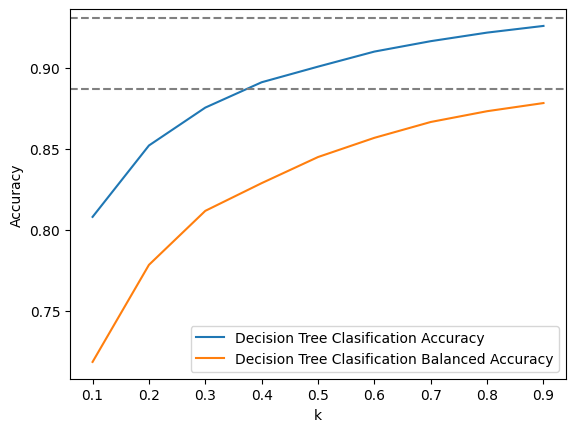

In [107]:
plt.plot(K, Acc_tree, label="Decision Tree Clasification Accuracy")
plt.plot(K, Acc_bac_tree, label="Decision Tree Clasification Balanced Accuracy")
plt.axhline(acc_tree, linestyle="--", color="gray")
plt.axhline(acc_tree_bac, linestyle="--", color="gray")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(K, Acc_forest, label="Random Forest Classification Accuracy")
plt.plot(K, Acc_bac_forest, label="Random Forest Classification Balanced Accuracy")
plt.axhline(acc_forest, linestyle="--", color="gray")
plt.axhline(acc_forest_bac, linestyle="--", color="gray")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.close()
#plt.show()

### Repeat the experiment with stratified sampling.

Compare the results of the two approaches (random vs stratified sampling) on the same plot.

Is this feasible in practice?

In [110]:
# write your code here
x_train_str, x_test_str, y_train_str, y_test_str = train_test_split(X, y, train_size=0.6, shuffle=True, stratify=y)

y_unique, y_counts = np.unique(y_train_str, return_counts=True)
y_unique_all, y_counts_all = np.unique(y, return_counts=True)

print(f"Distribution of targets trainset: {y_counts / y_train_str.shape[0]}")
print(f"Distribution of targets trainset: {y_counts_all / y.shape[0]}")

K = np.arange(0.1, 1, 0.1)
Acc_LR_str = np.zeros(K.size)
Acc_bac_LR_str = np.zeros(K.size)
Acc_tree_str = np.zeros(K.size)
Acc_bac_tree_str = np.zeros(K.size)
Acc_forest_str = np.zeros(K.size)
Acc_bac_forest_str = np.zeros(K.size)

for i, k in enumerate(K):
    print(k)
    #Acc_LR[i], Acc_bac_LR[i] = test_k(x_train, y_train, k, model=LogisticRegression()
    Acc_tree_str[i], Acc_bac_tree_str[i] = test_k(x_train_str, y_train_str, k, model=DecisionTreeClassifier(), stratify=True)
    #Acc_forest_str[i], Acc_bac_forest_str[i] = test_k(x_train_str, y_train_str, k, model=RandomForestClassifier(), stratify=True)

Distribution of targets trainset: [0.36460542 0.48760065 0.06153634 0.00472739 0.01633932 0.02989039
 0.0353005 ]
Distribution of targets trainset: [0.36460521 0.48759922 0.06153746 0.00472796 0.01633873 0.02989095
 0.03530048]
0.1
0.2
0.30000000000000004
0.4
0.5
0.6
0.7000000000000001
0.8
0.9


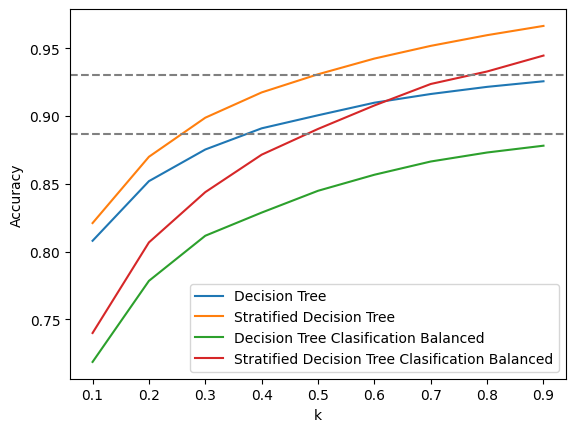

In [111]:
plt.plot(K, Acc_tree, label="Decision Tree")
plt.plot(K, Acc_tree_str, label="Stratified Decision Tree")
plt.plot(K, Acc_bac_tree, label="Decision Tree Clasification Balanced")
plt.plot(K, Acc_bac_tree_str, label="Stratified Decision Tree Clasification Balanced")
plt.axhline(acc_tree, linestyle="--", color="gray")
plt.axhline(acc_tree_bac, linestyle="--", color="gray")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(K, Acc_forest, label="Random Forest Classification")
plt.plot(K, Acc_forest_str, label="Stratified Random Forest Classification")
plt.plot(K, Acc_bac_forest, label="Random Forest Classification Balanced")
plt.plot(K, Acc_bac_forest_str, label="Stratified Random Forest Classification Balanced")
plt.axhline(acc_forest, linestyle="--", color="gray")
plt.axhline(acc_forest_bac, linestyle="--", color="gray")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.close()
#plt.show()

## 5*. Propose better sampling strategies. Compare them with random methods.

In [ ]:
# write your code here


